In [12]:
import numpy as np
import pandas as pd

In [13]:
df = pd.read_csv('placement.csv')

In [14]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [15]:
df.shape

(100, 4)

In [16]:
df = df.iloc[:,1:]


In [17]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [18]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


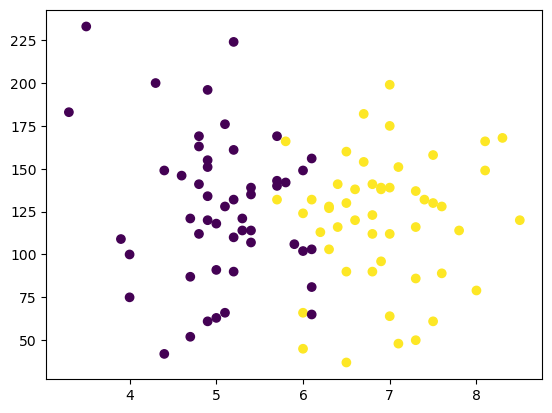

In [20]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [27]:
#Step 2:EXTRACT INPUT AND OUTPUT VARIABLES

X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [28]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [29]:
#TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.1)

In [30]:
X_train

,cgpa,iq
19,5.2,132.0
95,4.3,200.0
55,7.8,114.0
82,6.5,37.0
50,3.5,233.0
...,...,...
27,6.0,124.0
41,5.4,114.0
58,8.0,79.0
12,5.4,139.0


In [31]:
#SCALING VALUES BETWEEN -1 TO 1
from sklearn.preprocessing import StandardScaler

In [32]:
scaler = StandardScaler()

In [35]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [37]:
from sklearn.linear_model import LogisticRegression

In [38]:
clf = LogisticRegression()

In [39]:
#MODEL TRAINING
clf.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [44]:
y_pred = clf.predict(X_test)

In [45]:
y_test

83    1
45    1
0     1
96    0
71    1
32    1
29    1
80    0
43    1
30    1
Name: placement, dtype: int64

In [46]:
from sklearn.metrics import accuracy_score

In [47]:
accuracy_score(y_test,y_pred)

0.8

In [51]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

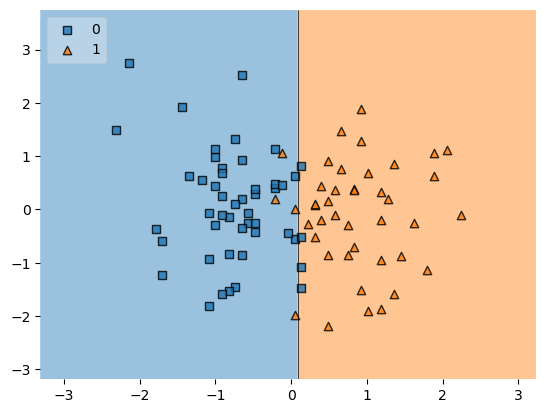

In [52]:
plot_decision_regions(X_train,y_train.values,clf = clf,legend = 2)

In [53]:
import pickle

In [54]:
pickle.dump(clf,open('model.pkl','wb'))